In [1]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Uniform
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.nn.bijective import rational_quadratic_spline
import matplotlib.pyplot as plt

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.autoregressive import AutoregressiveMLP, MaskedMLP, autoregressive_mask_getter
from probjax.nn.helpers import Flip, Permute

import optax
from optax import adam

import jax
from jax import numpy as jnp

# Normalizing flows

Constructing normalizing flows easily using the inverse interpreter!

In [2]:
input_dim = 2

In [3]:
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [4]:
# Mixture of Gaussians target distribution

target_samples1 = p.sample(jax.random.PRNGKey(0), (1000,)) + 5.0
target_samples2 = p.sample(jax.random.PRNGKey(1), (1000,)) - 5.0
xs = jnp.concatenate([target_samples1, target_samples2], axis=0)


### Affine flows

We have a coupling MLP combined with an affine bijector.

In [5]:
@jax.vmap
def affine_bijector(loc_and_scale, x):
    loc, scale = jnp.split(loc_and_scale, 2, axis=-1)
    scale = jax.nn.softplus(scale) + 0.5
    return loc + scale*x


bijector_dim = 2*(input_dim // 2)
split_dim = input_dim // 2

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([CouplingMLP(split_dim, affine_bijector, bijector_dim),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim), 
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim)])
    return nn(x)

params = forward.init(jax.random.PRNGKey(0), jnp.zeros((1, input_dim)))

# Parameterized invertibe transformation
T = forward.apply

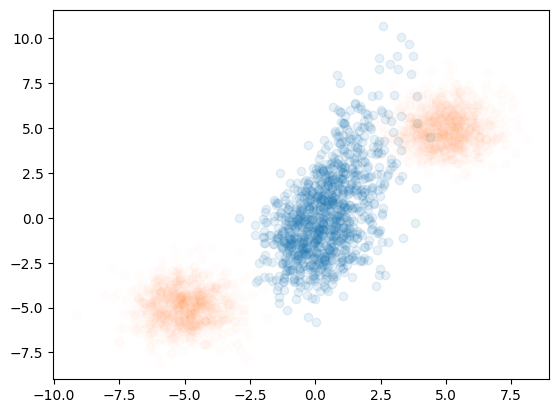

In [19]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))


plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [20]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [21]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

17.79105
4.2353168
3.826883
3.642222
3.5997508


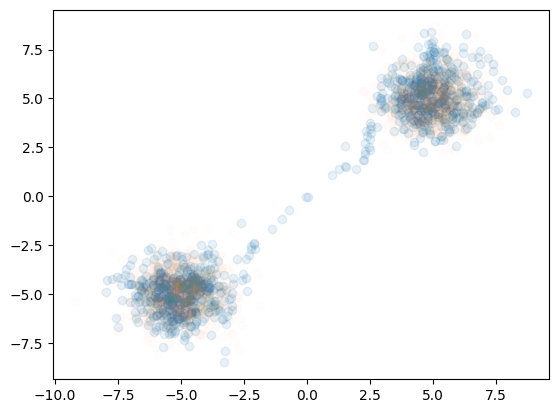

In [22]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))


plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [140]:
# High dimensional  

from probjax.utils.torchvision_datasets import NumpyLoader, MNIST

def transform_data(x):
    normed = (jnp.reshape(jnp.asarray(x, dtype=jnp.float32), (-1, 784)) + 1) / 256
    return normed

mnist_dataset = MNIST('/tmp/mnist/', download=True, transform=transform_data)
training_generator = NumpyLoader(mnist_dataset, batch_size=512, num_workers=0)

input_dim = 784

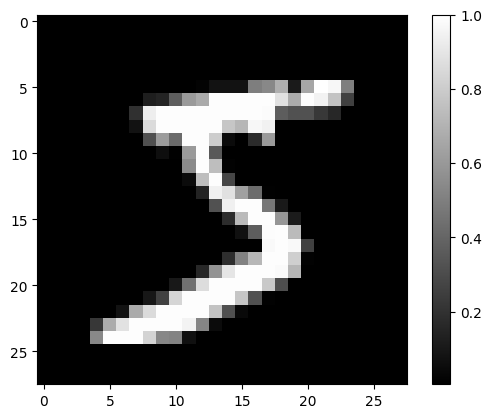

In [127]:
for x, y in training_generator:
    plt.imshow(x[0].reshape(28, 28), cmap='gray')
    plt.colorbar()
    break

In [214]:
@jax.vmap
def real_nvp(loc, x):
    scale, loc = jnp.split(loc, 2, axis=-1)
    scale = jnp.tanh(scale)*0.5 + 1.
    return loc + scale*x


bijector_dim = (input_dim // 2)*2
split_dim = input_dim // 2

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200,200 ]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(0), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]), 
                        Permute(jax.random.permutation(jax.random.PRNGKey(1), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(2), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(3), input_dim)), 
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(4), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(5), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(6), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(7), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(8), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(9), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(10), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(11), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(12), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(13), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(14), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(15), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(16), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(17), input_dim)),
                        CouplingMLP(split_dim, real_nvp, bijector_dim, hidden_dims=[200, 200]),
                        Permute(jax.random.permutation(jax.random.PRNGKey(18), input_dim)),
                        ])
    out = nn(x)

    return out

params = forward.init(jax.random.PRNGKey(0), jnp.zeros((100, input_dim)))

# Parameterized invertibe transformation
T = forward.apply

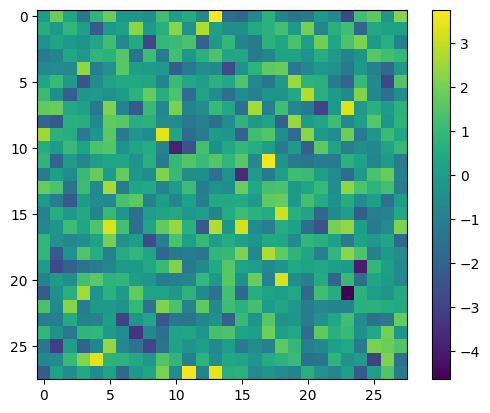

In [215]:
q = TransformedDistribution(Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1), lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (10,))

plt.imshow(samples[2].reshape(28, 28))
plt.colorbar()

In [216]:
optimizer = adam(5e-4)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(Independent(Normal(jnp.zeros(input_dim),jnp.ones(input_dim)), 1), lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [23]:
for i in range(10):
    for xs_batch, _ in training_generator:
        params, opt_state, loss = step(params, opt_state, xs_batch)
    print(loss)

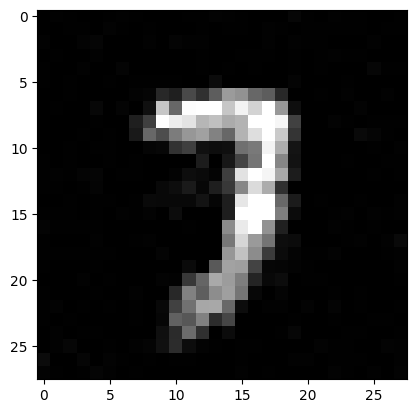

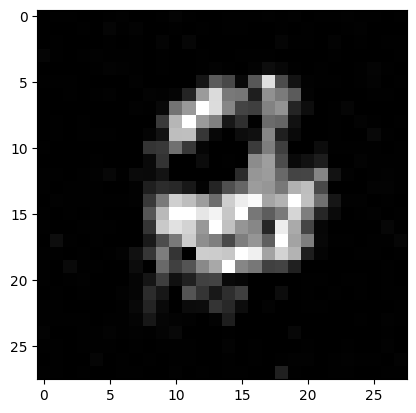

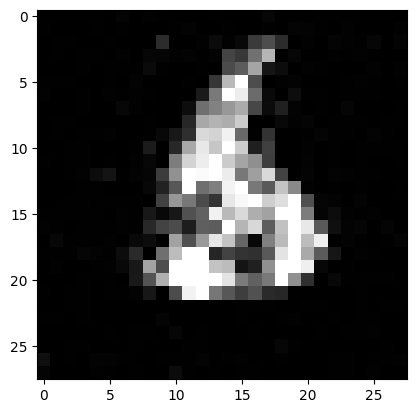

In [236]:
q = TransformedDistribution(Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1), lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(5), (10,))

for i in range( 3):
    plt.imshow(samples[i].reshape(28, 28), cmap='gray', vmin=0., vmax=1.)
    plt.show()

## Spline flows

In [7]:
@jax.vmap
def spline_bijector(params, x):
    return rational_quadratic_spline(params, x, range_min_x=-4, range_max_x=4,range_min_y = -15., range_max_y=15.)

num_bins = 4
bijector_dim = (3 * num_bins)
split_dim = input_dim // 2

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([CouplingMLP(1, spline_bijector, bijector_dim),Flip(), CouplingMLP(1, spline_bijector, bijector_dim), Flip()])
    return nn(x)

init, apply = forward.init, forward.apply
params = init(jax.random.PRNGKey(0), jnp.ones((10,input_dim,)))
T = apply

In [8]:
y = apply(params, jnp.ones((10,input_dim)))

q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

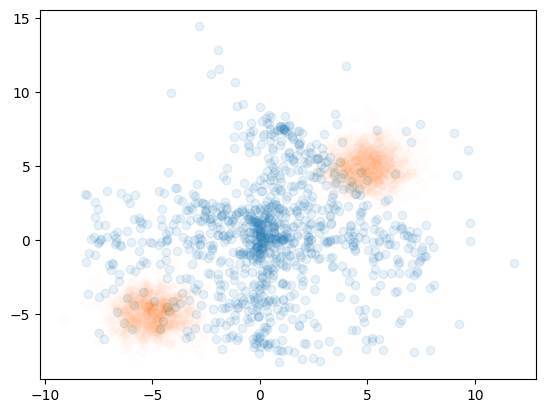

In [9]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [27]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [28]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

6.91106
3.5686438
3.577281
3.563361
3.5370574


In [29]:
q = TransformedDistribution(p, lambda x: apply(params, x))
samples = q.sample(jax.random.PRNGKey(0), sample_shape=(1000,))

(-10.0, 10.0)

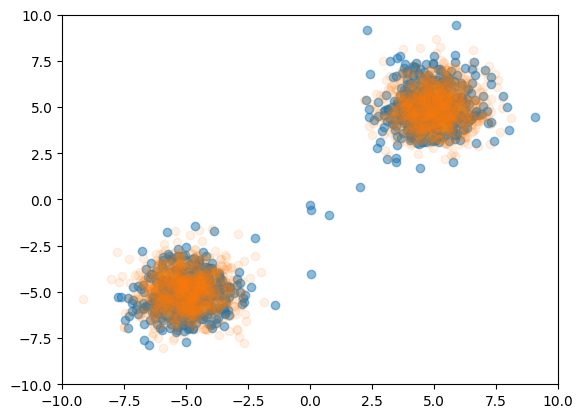

In [30]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)

plt.xlim(-10, 10)
plt.ylim(-10, 10)

# Continous normalizing flows

In [102]:
from probjax.utils.odeint import _odeint as odeint
from probjax.nn.helpers import TimeEmbedding
from functools import partial
def net(t, x):
    t = jnp.array(t).reshape(-1)
    t = TimeEmbedding(4)(t)
    return hk.nets.MLP([50, 50, 2], activation=jnp.tanh)(jnp.concatenate([t, x], axis=-1))
    
init, forward = hk.without_apply_rng(hk.transform(net))
params = init(jax.random.PRNGKey(0), jnp.ones(1), jnp.ones((2,)))
net_jac = jax.vmap(jax.jacfwd(forward, argnums=1), in_axes=(None, 0))

ts = jnp.linspace(0, 1, 200)

@partial(jax.vmap, in_axes=(0,None))
def g(x0, params):
    def drift(t, x):
        return forward(params, t, x)
    return odeint(drift, x0, ts)[-1]



@partial(jax.vmap, in_axes=(0,None))
def g_inv_log_det(x, params):

    net_jac = jax.jacobian(forward, argnums=2)

    def f_augmented(t, x):
        x0 = x[:-1]
        x1  =x[-1:]

        f0 = forward(params, t, x0)
        J = net_jac(params, t, x0)
        logdet = jnp.diagonal(J, axis1=-2, axis2=-1).sum(-1, keepdims=True)

        return jnp.concatenate([f0, logdet], axis=-1) 

    x = jnp.concatenate([x, jnp.zeros((1,))], axis=-1)
    y = odeint(f_augmented, x, ts[::-1])

    return y[-1, :-1], y[-1,-1:]

In [103]:
p = Independent(Normal(jnp.zeros(2), jnp.ones(2)), 1)

def sample(params, key, shape):
    z0 = p.sample(key, shape)
    z1 = g(z0, params)
    return z1

def log_prob(params, value):
    z0, logdet = g_inv_log_det(value, params)
    return p.log_prob(z0) + jnp.squeeze(logdet, axis=-1)

In [105]:
optimizer = adam(1e-2)
opt_state = optimizer.init(params)


def loss_fn(params, x):
    return -log_prob(params, x).mean()
    
@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [106]:
for i in range(500):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (256,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 50 == 0:
        print(loss)

29.182392
3.5929592
3.5872426
3.5211966
3.561514
3.5423105
3.4730182
3.5227008
3.622795
3.6060104


In [78]:
samples = sample(params, jax.random.PRNGKey(0), (1000,))

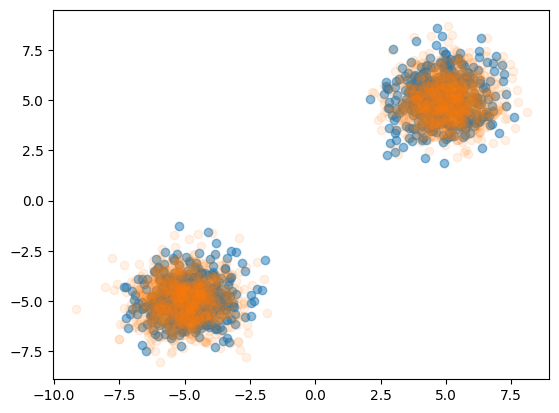

In [79]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)


# Flow matching

Flow Matching Objective (FM): The paper introduces the Flow Matching objective, which aims to match a target probability distribution to a known distribution by regressing a vector field. The goal is to flow from a simple distribution (e.g., standard normal) to a target distribution that closely approximates the data distribution.

Conditional Probability Paths and Vector Fields: To achieve the Flow Matching objective, the paper discusses the construction of conditional probability paths (pt(x|x1)) and vector fields (ut(x|x1)) per data sample. These conditional paths and fields are essential for modeling the target probability distribution.

Theorems: The paper presents several theorems, notably Theorem 1 and Theorem 2. Theorem 1 shows that the marginal vector field (ut) generates the marginal probability path (pt), linking conditional and marginal modeling. Theorem 2 demonstrates the equivalence of the Conditional Flow Matching (CFM) objective to the original FM objective, making CFM a more tractable choice.

Conditional Flow Matching (CFM): Due to intractable integrals in the original FM objective, the paper proposes CFM as a simpler alternative. CFM allows for easy unbiased sampling estimates and has identical gradients to the FM objective. It is defined by the loss function:

scss
Copy code
LCFM(θ) = Et,q(x1),pt(x|x1) [||vt(x) - ut(x|x1)||^2]
Construction of Conditional Paths: The paper provides examples of constructing conditional Gaussian probability paths, including diffusion conditional paths and optimal transport conditional paths.


In [247]:
from probjax.utils.odeint import _odeint as odeint
from probjax.nn.helpers import TimeEmbedding
from functools import partial

def net(t, x):
    t = jnp.array(t).reshape(-1)
    t = TimeEmbedding(4)(t)
    return hk.nets.MLP([50, 50, 2], activation=jnp.tanh)(jnp.concatenate([t, x], axis=-1))
    
init, forward = hk.without_apply_rng(hk.transform(net))
params = init(jax.random.PRNGKey(0), jnp.ones(1), jnp.ones((2,)))

ts = jnp.linspace(0, 1, 200)

def drift(t, x, params):
    return forward(params, t, x)


In [279]:
sigma_min = 1e-4

# Train as if it would be a diffusion process
def loss_fn(params, key, x1):
    """ Optimal transport flow-matching loss.
    """
    key1, key2, key3 = jax.random.split(key, 3)
    t = jax.random.uniform(key1, (x1.shape[0], 1))
    x0 = jax.random.normal(key2, x1.shape)
    noise = jax.random.normal(key3, x1.shape)

    # One possibility
    xt = t * x1 + (1 - t) * x0 + sigma_min * noise
    u = x1 - x0

    # Other: This does not work
    # xt = t * x1 + (t * sigma_min - t + 1) * noise
    # u = (x1 - (1- sigma_min) * x0) / (1 - (1- sigma_min) * t)
    return jnp.sum(jnp.square(jax.vmap(drift, in_axes=(0,0, None))(t, xt, params) - u), -1).mean()

optimizer = adam(1e-3)
opt_state = optimizer.init(params)
    
@jax.jit
def step(params, opt_state, key, x):
    loss, g = jax.value_and_grad(loss_fn)(params, key,x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [280]:
for i in range(1000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, jax.random.PRNGKey(i + 10000),xs_batch)
    if i % 100 == 0:
        print(loss)

3641.6987
13.229505
11.28201
12.225994
10.740582
9.958746
12.274471
11.6619005
10.835196
10.654689


In [284]:
def sample(params, key, shape):
    z0 = jax.random.normal(key, shape + (2,))
    def f(x0):
        return odeint(lambda t, x: drift(t, x, params), x0, jnp.linspace(0,1, 200), method="rk4")[-1]
    z1 = jax.vmap(f)(z0)
    return z1

In [285]:
samples = sample(params, jax.random.PRNGKey(0), (1000,))

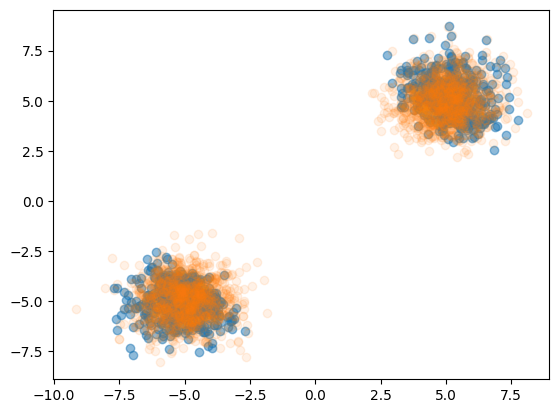

In [286]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)
